In [1]:
# Presentation:
# - Multi-Object

In [2]:
# reloads modules before executing
%load_ext autoreload
%autoreload 2

In [3]:
from classes.particle_filter import ParticleFilter
from classes.particle_filter_multiple import MultiObjectParticleFilter
from classes.observation import TransitionModel, ObservationModel
from classes.simulator import create_ground_truth, generate_random_balls, create_ground_truth_n_balls
from classes.plotting import plot_sim_n_balls_point_prediction, plot_particles_at_time, animate_particle_filter
from classes.evaluator import get_stats
from classes.tester import create_test_scenario, run_one_test
import numpy as np

In [4]:
np.random.seed()

STATE_BOUNDS = [
    (0.0, 50.0),   # x bounds
    (0.0, 50.0),   # y bounds
    (-30.0, 30.0),   # vx bounds
    (0.0, 40.0)    # vy bounds
]

# Simulation Parameters
dropout_start = -1
dropout_end = -1
process_noise = 1.0
measurement_noise = 5

true_states = generate_random_balls(1, STATE_BOUNDS)
n_objects = len(true_states)


true, observations, transition_model, observation_model = create_test_scenario(true_states,
                                                                                dropout_start, 
                                                                                dropout_end, 
                                                                                process_noise,
                                                                                measurement_noise,)

# Particle Filter Parameters
num_particles_per_ball = 1000


run_one_test(num_particles=num_particles_per_ball, 
            n_objects=n_objects,
            state_bounds=STATE_BOUNDS,
            transition_model=transition_model,
            observation_model=observation_model,
            init_generator="Sobol",
            roughening_noise=0,
            observations=observations,
            true_trajectory=true)



c:\THWS\THWS\1. Semester\RDM\New_Particle_Filter\classes\particle_filter_multiple.py:114: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


t=0  assignment={np.int64(0): np.int64(0)}
  ball 0: x=3.7  y=21.9  vx=-1.77  vy=18.42
t=1  assignment={np.int64(0): np.int64(0)}
  ball 0: x=4.9  y=23.1  vx=1.30  vy=18.84
t=2  assignment={np.int64(0): np.int64(0)}
  ball 0: x=8.1  y=24.4  vx=12.50  vy=17.35
t=3  assignment={np.int64(0): np.int64(0)}
  ball 0: x=8.3  y=27.1  vx=11.68  vy=20.25
t=4  assignment={np.int64(0): np.int64(0)}
  ball 0: x=10.1  y=28.6  vx=17.08  vy=19.56
t=5  assignment={np.int64(0): np.int64(0)}
  ball 0: x=10.5  y=29.5  vx=15.75  vy=19.57
t=6  assignment={np.int64(0): np.int64(0)}
  ball 0: x=14.6  y=30.9  vx=25.72  vy=18.55
t=7  assignment={np.int64(0): np.int64(0)}
  ball 0: x=16.9  y=31.0  vx=27.54  vy=17.21
t=8  assignment={np.int64(0): np.int64(0)}
  ball 0: x=16.9  y=33.0  vx=26.54  vy=17.54
t=9  assignment={np.int64(0): np.int64(0)}
  ball 0: x=20.1  y=35.7  vx=27.59  vy=17.29
t=10  assignment={np.int64(0): np.int64(0)}
  ball 0: x=19.8  y=36.9  vx=26.91  vy=17.46
t=11  assignment={np.int64(0): np.in

(np.float64(1.8029321772142548),
 np.float64(2.0249095593511606),
 np.float64(2.532742760516231),
 np.float64(2.913992683628949))

In [ ]:

n_objects = 1
step_size = 0.05
num_steps = 120
dropout_start = -1
dropout_end = -1
process_noise = 1

measurement_noise = 2
roughening_noise = 0


num_particles = 1000
init_generator = "Sobol"


# Crossing Each Other
# true_states_multi = np.array([
#     [20.0, 20.0, 2.0, 25.0],
#     [20.0, 20.0, 2.0, 30.0],
#     [30.0, 20.0, -2.0, 25.0],
#     [30.0, 20.0, -2.0, 30.0]
# ], dtype=float)

# Similar Trajectories
# true_states_multi = np.array([
#     [5.0, 5.0, 18.0, 25.0],
#     [5.0, 5.0, 18.0, 30.0],
#     [5.0, 5.0, 18.0, 35.0],
#     [5.0, 5.0, 18.0, 40.0]
# ], dtype=float)

# Create multi-ball physics models
true_states_multi = generate_random_balls(n_objects, state_bounds)

transition_model = TransitionModel(delta_t=step_size, process_noise=1)

observation_model = ObservationModel("Gaussian", measurement_noise=measurement_noise)
model_transition_model = TransitionModel(delta_t=step_size, process_noise=process_noise)

# Generate multi-ball paths and sensor reads
true_trajectory_multi, observations_multi = create_ground_truth_n_balls(
    num_steps, dropout_start, dropout_end, true_states_multi, transition_model, observation_model
)

# Initialize Particle Filter with expanded particle cloud for multi-modality
pf_multi = MultiObjectParticleFilter(
    num_particles=num_particles,
    n_balls=n_objects,
    state_bounds=state_bounds,
    transition_model=model_transition_model,
    observation_model=observation_model,
    init_generator=init_generator,
    roughening_noise=roughening_noise,
)

# pf_single = ParticleFilter(
#     num_particles=num_particles * n_objects,  # more particles to equalize playing field
#     state_bounds=state_bounds,
#     transition_model=model_transition_model,
#     observation_model=observation_model,
#     init_generator=init_generator,
#     roughening_noise=roughening_noise
# )

# Run the tracking engine
history_multi = pf_multi.run(observations_multi)

# history_single = pf_single.run(observations_multi, n_objects=n_objects)


t=0  assignment={np.int64(0): np.int64(0)}
  ball 0: x=17.2  y=21.9  vx=-6.27  vy=20.42


c:\THWS\THWS\1. Semester\RDM\New_Particle_Filter\classes\particle_filter_multiple.py:114: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


t=1  assignment={np.int64(0): np.int64(0)}
  ball 0: x=16.4  y=23.1  vx=-9.75  vy=20.78
t=2  assignment={np.int64(0): np.int64(0)}
  ball 0: x=16.0  y=22.2  vx=-12.05  vy=15.82
t=3  assignment={np.int64(0): np.int64(0)}
  ball 0: x=14.9  y=23.0  vx=-16.61  vy=15.04
t=4  assignment={np.int64(0): np.int64(0)}
  ball 0: x=12.8  y=24.9  vx=-19.29  vy=19.18
t=5  assignment={np.int64(0): np.int64(0)}
  ball 0: x=11.9  y=23.4  vx=-21.95  vy=7.29
t=6  assignment={np.int64(0): np.int64(0)}
  ball 0: x=11.5  y=27.5  vx=-17.78  vy=27.28
t=7  assignment={np.int64(0): np.int64(0)}
  ball 0: x=10.2  y=26.2  vx=-18.80  vy=16.89
t=8  assignment={np.int64(0): np.int64(0)}
  ball 0: x=10.6  y=28.2  vx=-15.34  vy=21.74
t=9  assignment={np.int64(0): np.int64(0)}
  ball 0: x=8.1  y=26.8  vx=-19.01  vy=13.49
t=10  assignment={np.int64(0): np.int64(0)}
  ball 0: x=7.3  y=26.0  vx=-21.23  vy=8.04
t=11  assignment={np.int64(0): np.int64(0)}
  ball 0: x=6.8  y=26.7  vx=-20.09  vy=9.20
t=12  assignment={np.int64

In [15]:
# plot_sim_n_balls_point_prediction(
#     true_trajectory_multi,
#     observations_multi,
#     history_single,
#     dropout_start,
#     dropout_end
# )

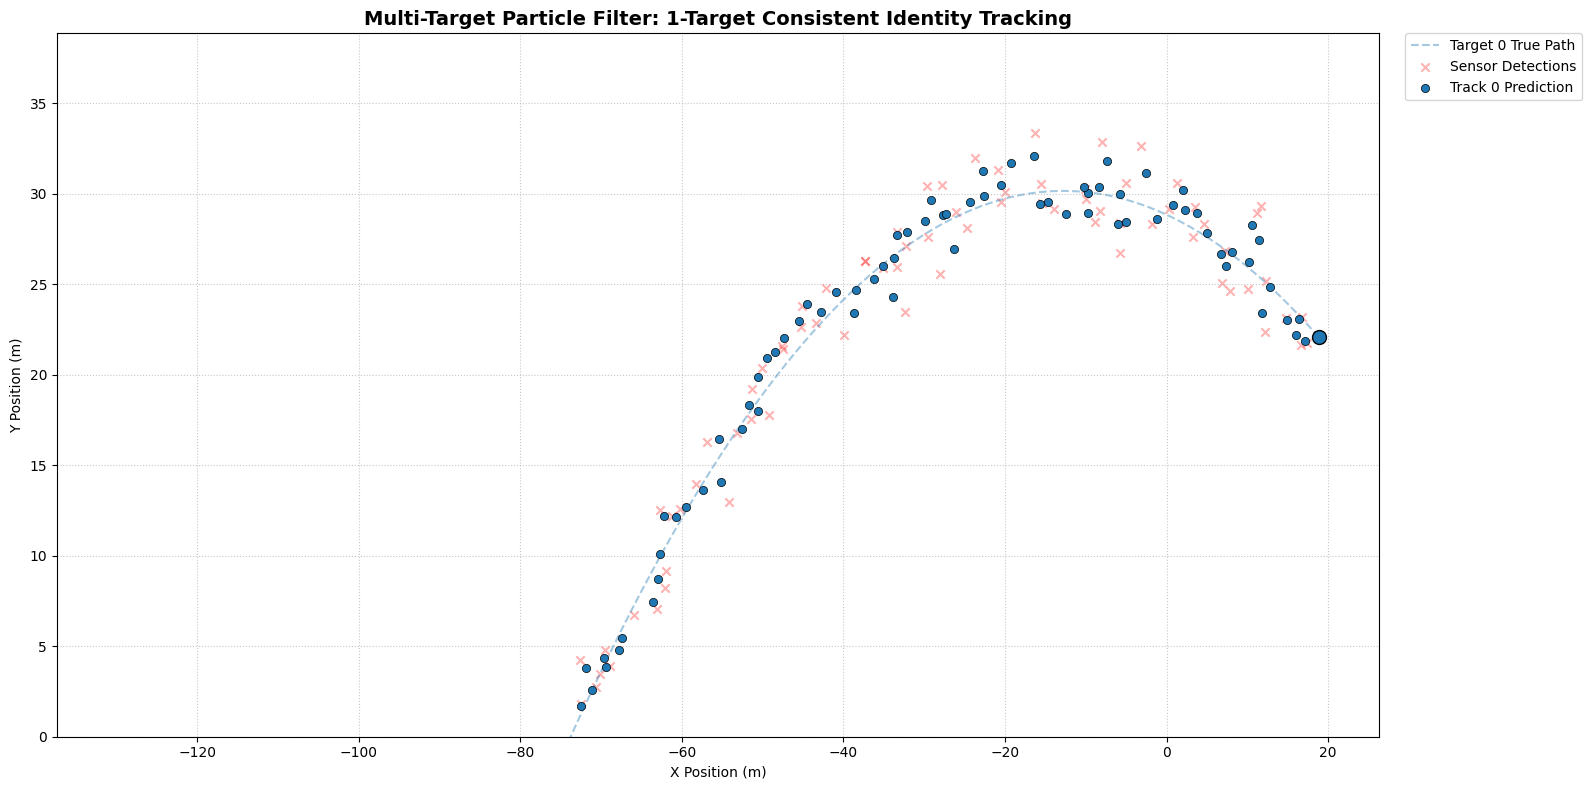

In [16]:
plot_sim_n_balls_point_prediction(
    true_trajectory_multi,
    observations_multi,
    history_multi,
    dropout_start,
    dropout_end
)

In [ ]:
# animate_particle_filter(true_trajectory_multi, history_multi, save_path="particle_filter_multiple_animation.gif")
# animate_particle_filter(true_trajectory_multi, history_single, save_path="particle_filter_single_animation.gif")


Animation saved to particle_filter_multiple_animation.gif


In [ ]:
# from PIL import Image
# import io
# import ipywidgets as widgets
# from IPython.display import display

# # load frames from GIF
# gif_path = "particle_filter_multiple_animation.gif"
# pil = Image.open(gif_path)
# frames_bytes = []
# try:
#     i = 0
#     while True:
#         pil.seek(i)
#         buf = io.BytesIO()
#         pil.convert("RGBA").save(buf, format="PNG")
#         frames_bytes.append(buf.getvalue())
#         i += 1
# except EOFError:
#     pass

# # widgets
# img = widgets.Image(value=frames_bytes[0], format='png', width=640*2, height=480*2)
# slider = widgets.IntSlider(min=0, max=len(frames_bytes)-1, description='Frame')
# play = widgets.Play(min=0, max=len(frames_bytes)-1, interval=200)

# widgets.jslink((play, 'value'), (slider, 'value'))

# def on_frame_change(change):
#     img.value = frames_bytes[change['new']]

# slider.observe(on_frame_change, names='value')

# controls = widgets.HBox([play, slider])
# display(controls, img)

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x06@\x00\x00\x03 \x08\x06\x00\x00\x00{\xc0\xaeZ\x00\…

In [19]:
# from PIL import Image
# import io
# import ipywidgets as widgets
# from IPython.display import display

# # load frames from GIF
# gif_path = "particle_filter_single_animation.gif"
# pil = Image.open(gif_path)
# frames_bytes = []
# try:
#     i = 0
#     while True:
#         pil.seek(i)
#         buf = io.BytesIO()
#         pil.convert("RGBA").save(buf, format="PNG")
#         frames_bytes.append(buf.getvalue())
#         i += 1
# except EOFError:
#     pass

# # widgets
# img = widgets.Image(value=frames_bytes[0], format='png', width=640*2, height=480*2)
# slider = widgets.IntSlider(min=0, max=len(frames_bytes)-1, description='Frame')
# play = widgets.Play(min=0, max=len(frames_bytes)-1, interval=200)

# widgets.jslink((play, 'value'), (slider, 'value'))

# def on_frame_change(change):
#     img.value = frames_bytes[change['new']]

# slider.observe(on_frame_change, names='value')

# controls = widgets.HBox([play, slider])
# display(controls, img)

In [ ]:

get_stats(true_trajectory_multi, observations_multi, history_multi, num_steps)
# print_stats(true_trajectory_multi, observations_multi, history_single, num_steps)

Estimate Mean error: 1.3105053380242089
Estimate RMSE: 1.4601578235764887
Observation Mean error: 1.8699414275838615
Observation RMSE: 2.14447062577817
